In [1]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.recommend_model import (
    LinearRecommender,
    RandomForestRecommender,
    CatBoostRecommender,
    NCFRecommender
)

In [2]:
df = pd.read_csv("../data/recommender_training.csv")

# --- split user ---
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# 2) Val 15%, Test 15%
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (82555, 12)
Val  : (17690, 12)
Test : (17691, 12)


In [3]:
linear = LinearRecommender()
linear.train(train_df)
linear.save("../models/linearregression_rec.pkl")

rf = RandomForestRecommender()
rf.train(train_df)
rf.save("../models/randomforest_rec.pkl")

[LinearRegression] Training finished.
✓ [LinearRegression] Model saved to ../models/linearregression_rec.pkl
[RandomForest] Training finished.
✓ [RandomForest] Model saved to ../models/randomforest_rec.pkl


[CatBoost] Training finished.


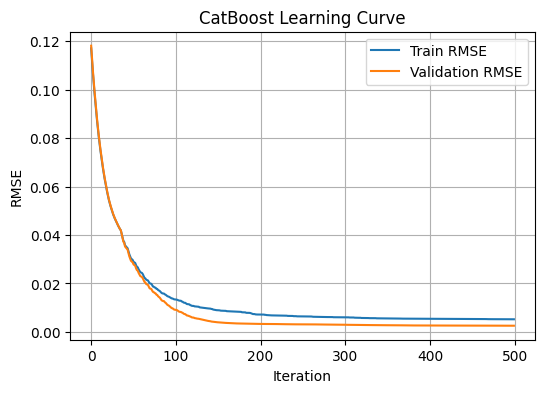

✓ [CatBoost] Model saved to ../models/catboost_rec.pkl


In [4]:
cat = CatBoostRecommender()
cat.train(train_df, val_df)

train_rmse = cat.evals_result["learn"]["RMSE"]
val_rmse   = cat.evals_result["validation"]["RMSE"]

plt.figure(figsize=(6,4))
plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("CatBoost Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

cat.save("../models/catboost_rec.pkl")

[NCF] Epoch 1/100 | Train MSE: 0.0417 | Val MSE: 0.0176
[NCF] Epoch 2/100 | Train MSE: 0.0151 | Val MSE: 0.0140
[NCF] Epoch 3/100 | Train MSE: 0.0125 | Val MSE: 0.0123
[NCF] Epoch 4/100 | Train MSE: 0.0112 | Val MSE: 0.0115
[NCF] Epoch 5/100 | Train MSE: 0.0105 | Val MSE: 0.0112
[NCF] Epoch 6/100 | Train MSE: 0.0102 | Val MSE: 0.0110
[NCF] Epoch 7/100 | Train MSE: 0.0099 | Val MSE: 0.0108
[NCF] Epoch 8/100 | Train MSE: 0.0096 | Val MSE: 0.0106
[NCF] Epoch 9/100 | Train MSE: 0.0094 | Val MSE: 0.0106
[NCF] Epoch 10/100 | Train MSE: 0.0092 | Val MSE: 0.0105
[NCF] Epoch 11/100 | Train MSE: 0.0090 | Val MSE: 0.0105
[NCF] Epoch 12/100 | Train MSE: 0.0088 | Val MSE: 0.0102
[NCF] Epoch 13/100 | Train MSE: 0.0086 | Val MSE: 0.0102
[NCF] Epoch 14/100 | Train MSE: 0.0084 | Val MSE: 0.0101
[NCF] Epoch 15/100 | Train MSE: 0.0083 | Val MSE: 0.0101
[NCF] Epoch 16/100 | Train MSE: 0.0081 | Val MSE: 0.0102
[NCF] Epoch 17/100 | Train MSE: 0.0080 | Val MSE: 0.0100
[NCF] Epoch 18/100 | Train MSE: 0.0079 |

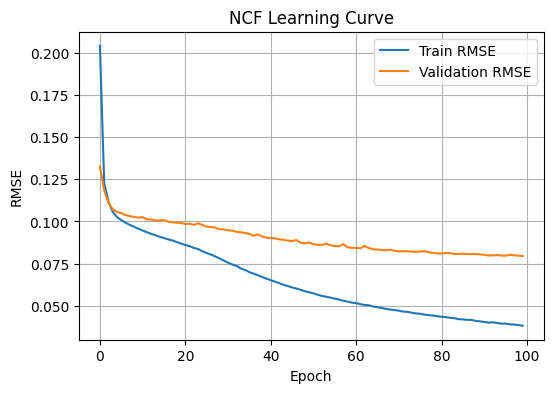

✓ [NCF] Model saved to ../models/ncf_rec.pkl


In [5]:
ncf = NCFRecommender()
ncf.train(train_df, val_df)

plt.figure(figsize=(6,4))
plt.plot(np.sqrt(ncf.train_losses), label="Train RMSE")
plt.plot(np.sqrt(ncf.val_losses), label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("NCF Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

ncf.save("../models/ncf_rec.pkl")

In [6]:
def evaluate_regression_model(recommender, df):
    """
    Đánh giá regression thuần (label prediction)
    """
    df = recommender.feature_engineering(df)

    if "CatBoost" in recommender.model_name:
        for col in recommender.cat_features:
            df[col] = df[col].astype(str).fillna("unknown")

        X = df[recommender.features]

    else:
        df = recommender.transform_encoders(df)
        X = df[recommender.features]
        if recommender.scaler:
            X = recommender.scaler.transform(X)

    y = df["label"]

    return recommender.evaluate(X, y)


In [7]:
def build_ground_truth(df, top_n=5):
    return (
        df.sort_values("label", ascending=False)
          .groupby("user_id")
          .head(top_n)
          .groupby("user_id")["poi_id"]
          .apply(set)
          .to_dict()
    )

In [8]:
def precision_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    return len(set(rec_k) & relevant) / k

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)

In [9]:
def evaluate_recommender(recommender, df_test, poi_df, k=10):
    gt = build_ground_truth(df_test, top_n=k)

    precisions, recalls = [], []
    skipped = 0

    for user_id, relevant_pois in gt.items():

        # --- SKIP cold-start user cho NCF ---
        if recommender.model_name == "NCF":
            if user_id not in recommender.user_encoder.classes_:
                skipped += 1
                continue

        city, user_type, price = user_id.split("_")

        candidate_ids = df_test[df_test["user_id"] == user_id]["poi_id"]
        candidate_pois = poi_df[poi_df["poi_id"].isin(candidate_ids)]

        if candidate_pois.empty:
            continue

        recs = recommender.recommend(
            df_raw=candidate_pois,
            city=city,
            user_type=user_type,
            user_price=int(price),
            top_k=k
        )

        if recs.empty:
            continue

        recommended_pois = recs["poi_id"].tolist()

        precisions.append(len(set(recommended_pois) & relevant_pois) / k)
        recalls.append(len(set(recommended_pois) & relevant_pois) / max(1, len(relevant_pois)))

    return {
        f"Precision@{k}": np.mean(precisions) if precisions else 0.0,
        f"Recall@{k}": np.mean(recalls) if recalls else 0.0
    }

In [10]:
poi_df = pd.read_csv("../data/POI.csv")

cat = CatBoostRecommender()
cat.load("../models/catboost_rec.pkl")

ncf = NCFRecommender()
ncf.load("../models/ncf_rec.pkl")

linear = LinearRecommender()
linear.load("../models/linearregression_rec.pkl")

rf = RandomForestRecommender()
rf.load("../models/randomforest_rec.pkl")

print("=== REGRESSION METRICS ===")
print("Linear:", evaluate_regression_model(linear, test_df))
print("RandomForest:", evaluate_regression_model(rf, test_df))
print("CatBoost:", evaluate_regression_model(cat, test_df))


print("=== RANKING METRICS ===")
print("Linear:", evaluate_recommender(linear, test_df, poi_df))
print("RandomForest:", evaluate_recommender(rf, test_df, poi_df))
print("CatBoost:", evaluate_recommender(cat, test_df, poi_df))
print("NCF:", evaluate_recommender(ncf, test_df, poi_df))


✓ [CatBoost] Model loaded.
✓ [NCF] Model loaded
✓ [LinearRegression] Model loaded.
✓ [RandomForest] Model loaded.
=== REGRESSION METRICS ===
Linear: {'MAE': 0.06382717198723677, 'RMSE': np.float64(0.08462653421226289), 'R2': 0.5296186527262834}
RandomForest: {'MAE': 0.00244394162666511, 'RMSE': np.float64(0.008757286604327291), 'R2': 0.9949629517850048}
CatBoost: {'MAE': 0.000920014146328136, 'RMSE': np.float64(0.002415732384940156), 'R2': 0.999616703702467}
=== RANKING METRICS ===
Linear: {'Precision@10': np.float64(0.4373844121532365), 'Recall@10': np.float64(0.739101717305152)}
RandomForest: {'Precision@10': np.float64(0.6464993394980185), 'Recall@10': np.float64(0.9482166446499339)}
CatBoost: {'Precision@10': np.float64(0.6686922060766183), 'Recall@10': np.float64(0.9704095112285337)}
NCF: {'Precision@10': np.float64(0.4644793152639087), 'Recall@10': np.float64(0.7184022824536377)}


In [11]:
# ===== FINAL TRAIN DATA (train + val) =====
full_train_df = pd.concat([train_df, val_df], ignore_index=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Final Train (train+val):", full_train_df.shape)

final_cat = CatBoostRecommender()

# Train trên toàn bộ train + val
final_cat.train(full_train_df)

# Save model FINAL
final_cat.save("../models/catboost_rec_final.pkl")

Train: (82555, 12)
Val  : (17690, 12)
Final Train (train+val): (100245, 12)
[CatBoost] Training finished.
✓ [CatBoost] Model saved to ../models/catboost_rec_final.pkl


In [12]:
top_poi = final_cat.recommend(
    df_raw=poi_df,
    city="ha noi",
    user_type="entertainment",
    user_price=0,
    top_k=10
)

print(top_poi)

              poi_id                                               name  \
168  attraction00630  Rentabike Vietnam West Lake - Motorbike Rental...   
126  attraction00588                                     Hoàn Kiếm Lake   
103  attraction00564                           Sword Lake Octagon House   
122  attraction00584                                      Cau Giay Park   
106  attraction00567                                 Indira Gandhi Park   
118  attraction00580                                  Ho Tay Water Park   
63   attraction00473                                            Hồ Đôla   
10   attraction00418                          Văn Phòng Trung Ương Đảng   
56   attraction00466                                 Cổng làng Nghĩa Đô   
27   attraction00437                                        Thọ Quạt cổ   

        score   latitude   longitude    poi_type  poi_price  price  
168  0.845271  21.062140  105.825567     natural          0      0  
126  0.845265  21.028667  105.852148